## Shapiro-Wilk Test For Normality

In [3]:
import pandas as pd
from scipy.stats import shapiro, probplot
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('../../data/incomes.csv')

The Shapiro-Wilk test statistic is 0.9786184063213592
The Shapiro-Wilk test statistic p-value is 0.7585228300258678
Fail to reject H0 of normality at alpha=0.05
0.7585228300258678


(array([3., 2., 4., 2., 4., 7., 3., 3., 3., 1.]),
 array([25767. , 31840.3, 37913.6, 43986.9, 50060.2, 56133.5, 62206.8,
        68280.1, 74353.4, 80426.7, 86500. ]),
 <BarContainer object of 10 artists>)

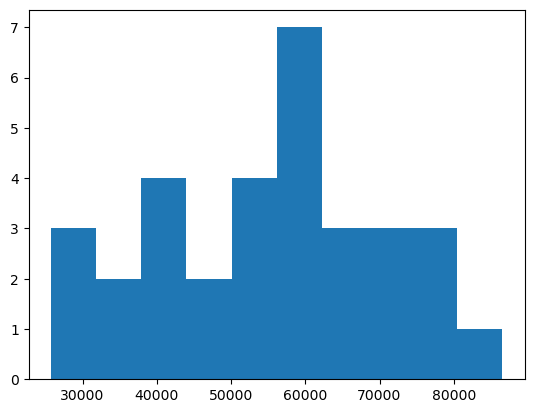

In [17]:
#Statistical test for normally distributed residuals - Shapiro-Wilk
#HO: Normally distributed data, HA: Non-normally distributed data
#If p-value is less than alpha, reject null of normally distributed data
shapiro_test = shapiro(df['Income_Normal'])
shapiro_stat = shapiro_test[0]
shapiro_p = shapiro_test[1]

print(f'The Shapiro-Wilk test statistic is {shapiro_stat}')
print(f'The Shapiro-Wilk test statistic p-value is {shapiro_p}')

alpha = 0.05

if shapiro_p < alpha:
    print(f"Reject normality at alpha={alpha}")
else:
    print(f"Fail to reject H0 of normality at alpha={alpha}")    
print(shapiro_p)
    
plt.hist(df['Income_Normal'])

The Shapiro-Wilk test statistic is 0.925245920856373
The Shapiro-Wilk test statistic p-value is 0.02892069191676332
Reject normality at alpha=0.05
0.02892069191676332


(array([4., 1., 3., 6., 3., 1., 3., 2., 2., 7.]),
 array([26673. , 32203.2, 37733.4, 43263.6, 48793.8, 54324. , 59854.2,
        65384.4, 70914.6, 76444.8, 81975. ]),
 <BarContainer object of 10 artists>)

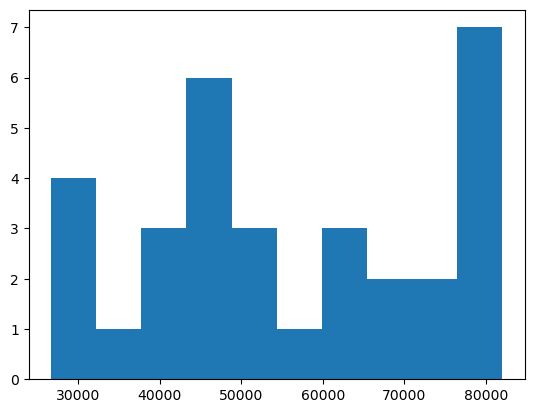

In [16]:
#Statistical test for normally distributed residuals - Shapiro-Wilk
#HO: Normally distributed data, HA: Non-normally distributed data
#If p-value is less than alpha, reject null of normally distributed data
shapiro_test = shapiro(df['Income_Uniform'])
shapiro_stat = shapiro_test[0]
shapiro_p = shapiro_test[1]

print(f'The Shapiro-Wilk test statistic is {shapiro_stat}')
print(f'The Shapiro-Wilk test statistic p-value is {shapiro_p}')

alpha = 0.05

if shapiro_p < alpha:
    print(f"Reject normality at alpha={alpha}")
else:
    print(f"Fail to reject H0 of normality at alpha={alpha}")    
print(shapiro_p)
        
plt.hist(df['Income_Uniform'])

# Issues w/ Shapiro-Wilk

mixture: n=30 | W=0.974423 | p=0.665748
Fail to reject normality at alpha=0.05.

mixture: n=80 | W=0.989066 | p=0.735282
Fail to reject normality at alpha=0.05.

mixture: n=200 | W=0.961281 | p=2.72797e-05
Reject normality at alpha=0.05.

mixture: n=1000 | W=0.992639 | p=7.18143e-05
Reject normality at alpha=0.05.

mixture: n=5000 | W=0.997464 | p=2.12895e-07
Reject normality at alpha=0.05.



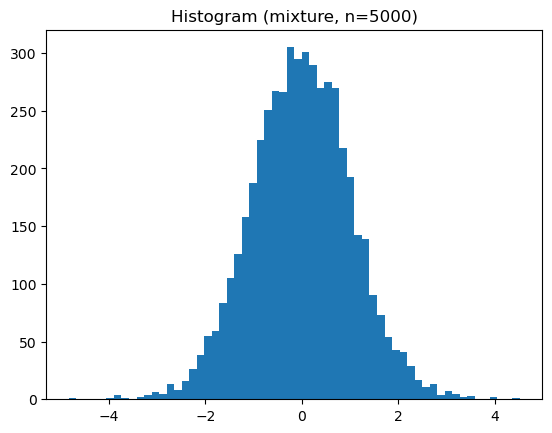

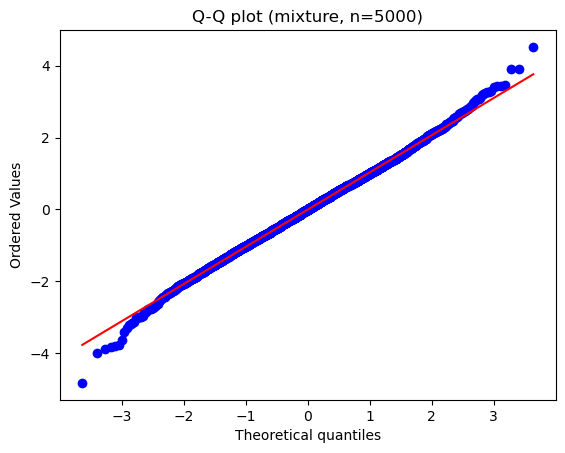

In [6]:
#Small n passes, big n fails
def shapiro_report(x, name="x", alpha=0.05):
    stat, p = shapiro(x)
    print(f"{name}: n={len(x)} | W={stat:.6f} | p={p:.6g}")
    if p < alpha:
        print(f"Reject normality at alpha={alpha}.")
    else:
        print(f"Fail to reject normality at alpha={alpha}.")
    print()

def heavy_tail_mixture(n, w=0.97, sigma_big=2.0):
    # with prob w: N(0,1); with prob 1-w: N(0, sigma_big^2)
    z1 = np.random.normal(0, 1, n)
    z2 = np.random.normal(0, sigma_big, n)
    mix = np.random.rand(n) < w
    return np.where(mix, z1, z2)

for n in [30, 80, 200, 1000, 5000]:
    x = heavy_tail_mixture(n)
    shapiro_report(x, name="mixture")

#Visual for the biggest sample
x = heavy_tail_mixture(5000)
plt.figure()
plt.hist(x, bins=60)
plt.title("Histogram (mixture, n=5000)")

plt.figure()
probplot(x, dist="norm", plot=plt)
plt.title("Q-Q plot (mixture, n=5000)")
plt.show()

normal (no outlier): n=200 | W=0.995134 | p=0.769433
Fail to reject normality at alpha=0.05.

normal + 1 outlier: n=200 | W=0.895470 | p=1.30576e-10
Reject normality at alpha=0.05.



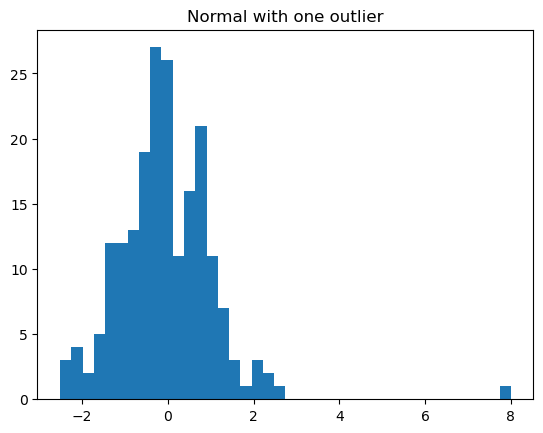

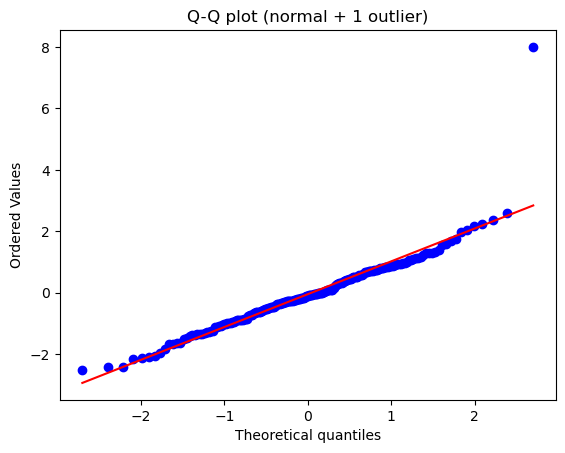

In [10]:
#Outlier Sensitivity
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

n = 200
x = np.random.normal(0, 1, n)
shapiro_report(x, "normal (no outlier)")

x_out = x.copy()
x_out[0] = 8  # one outlier
shapiro_report(x_out, "normal + 1 outlier")

plt.figure()
plt.hist(x_out, bins=40)
plt.title("Normal with one outlier")

plt.figure()
probplot(x_out, dist="norm", plot=plt)
plt.title("Q-Q plot (normal + 1 outlier)")
plt.show()


In [11]:
#Passes but doesn't look normal 
def trial(n=25, reps=200):
    reject = 0
    for _ in range(reps):
        x = np.random.exponential(scale=1.0, size=n)  # clearly skewed
        _, p = shapiro(x)
        reject += (p < 0.05)
    return reject / reps

for n in [15, 25, 40, 60, 100]:
    rate = trial(n=n, reps=300)
    print(f"Exponential data: n={n} | reject-rate at alpha=0.05 ≈ {rate:.2f}")


Exponential data: n=15 | reject-rate at alpha=0.05 ≈ 0.68
Exponential data: n=25 | reject-rate at alpha=0.05 ≈ 0.93
Exponential data: n=40 | reject-rate at alpha=0.05 ≈ 1.00
Exponential data: n=60 | reject-rate at alpha=0.05 ≈ 1.00
Exponential data: n=100 | reject-rate at alpha=0.05 ≈ 1.00
